# Clase 3 — Matplotlib y visualización

**Python y Políticas Públicas**

---

## Contenidos
1. Buenas prácticas en visualización de datos
2. Anatomía de un gráfico en matplotlib
3. Line plots y series temporales
4. Bar charts
5. Histogramas
6. Scatter plots
7. Heatmaps y matrices de correlación
8. Subplots: múltiples paneles
9. Exportar gráficos
10. Ejercicios

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Para que los gráficos aparezcan inline en el notebook
%matplotlib inline

# Estilo general
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Paleta de identidad del curso ---
C = ['#2A6496', '#E07B3F', '#3D9970', '#8E5EA2', '#C0A830', '#637A8A']

mpl.rcParams.update({
    'figure.figsize'       : (10, 5),
    'font.size'            : 11,
    'axes.titlesize'       : 12,
    'axes.titleweight'     : 'normal',
    'axes.spines.top'      : False,
    'axes.spines.right'    : False,
    'legend.frameon'       : False,
    'axes.prop_cycle'      : mpl.cycler(color=C),
    'figure.dpi'           : 110,
})

def tit(ax, t, **kw):
    """Título sin negrita, alineado a la izquierda."""
    ax.set_title(t, loc='left', fontweight='normal', **kw)


---
## 1. Buenas prácticas en visualización de datos

Un buen gráfico comunica un mensaje claro. Algunas reglas prácticas:

| Hacer | Evitar |
|-------|--------|
| Título descriptivo que cuente el hallazgo | Títulos genéricos ("Gráfico 1") |
| Etiquetar ambos ejes con unidades | Ejes sin etiqueta |
| Usar colores con propósito | Demasiados colores sin sentido |
| Empezar el eje Y en 0 (para barras) | Truncar el eje Y para exagerar diferencias |
| Fuente de los datos | Omitir la fuente |
| Menos es más: eliminar grilla innecesaria | Sobrecargar con elementos decorativos |

**¿Qué gráfico usar según el tipo de variable?**

| Tipo de análisis | Gráfico recomendado |
|------------------|---------------------|
| Evolución en el tiempo | Line plot |
| Comparar categorías | Bar chart (horizontal si hay muchas) |
| Distribución de una variable | Histograma |
| Relación entre dos variables numéricas | Scatter plot |
| Correlaciones entre múltiples variables | Heatmap |
| Composición (partes de un todo) | Pie chart (con moderación) |

---
## 2. Anatomía de un gráfico en matplotlib

Matplotlib tiene dos enfoques:
- **pyplot interface** (`plt.plot()`): rápido para gráficos simples.
- **Orientado a objetos** (`fig, ax = plt.subplots()`): recomendado para gráficos más elaborados.

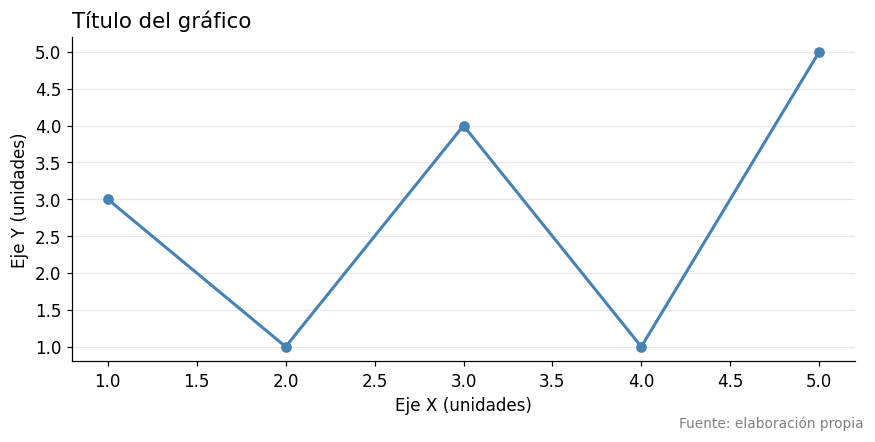

In [3]:
# Anatomía básica de un gráfico (enfoque recomendado)
fig, ax = plt.subplots(figsize=(8, 4))

x = [1, 2, 3, 4, 5]
y = [3, 1, 4, 1, 5]

ax.plot(x, y, marker='o', color='steelblue', linewidth=2)

ax.set_title("Título del gráfico", fontsize=14, loc='left')
ax.set_xlabel("Eje X (unidades)")
ax.set_ylabel("Eje Y (unidades)")
ax.grid(axis='y', alpha=0.3)

# Nota de fuente
fig.text(0.99, 0.01, "Fuente: elaboración propia", ha='right', fontsize=9, color='gray')

plt.tight_layout()
plt.show()


---
## 3. Line plots y series temporales

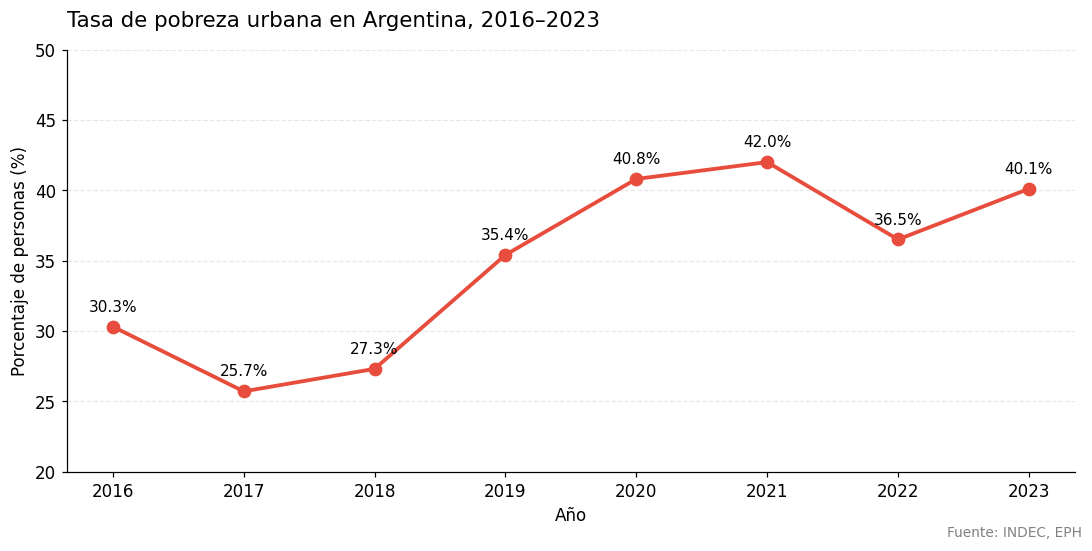

In [4]:
# Evolución de la tasa de pobreza nacional
anios = np.arange(2016, 2024)
pobreza = np.array([30.3, 25.7, 27.3, 35.4, 40.8, 42.0, 36.5, 40.1])

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(anios, pobreza, marker='o', color='#e74c3c', linewidth=2.5, markersize=8)

# Anotar cada punto
for x, y in zip(anios, pobreza):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)

ax.set_title("Tasa de pobreza urbana en Argentina, 2016–2023", fontsize=14, pad=15, loc='left')
ax.set_xlabel("Año")
ax.set_ylabel("Porcentaje de personas (%)")
ax.set_ylim(20, 50)
ax.set_xticks(anios)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.99, 0.01, "Fuente: INDEC, EPH", ha='right', fontsize=9, color='gray')
plt.tight_layout()
plt.show()


---
## 4. Bar charts

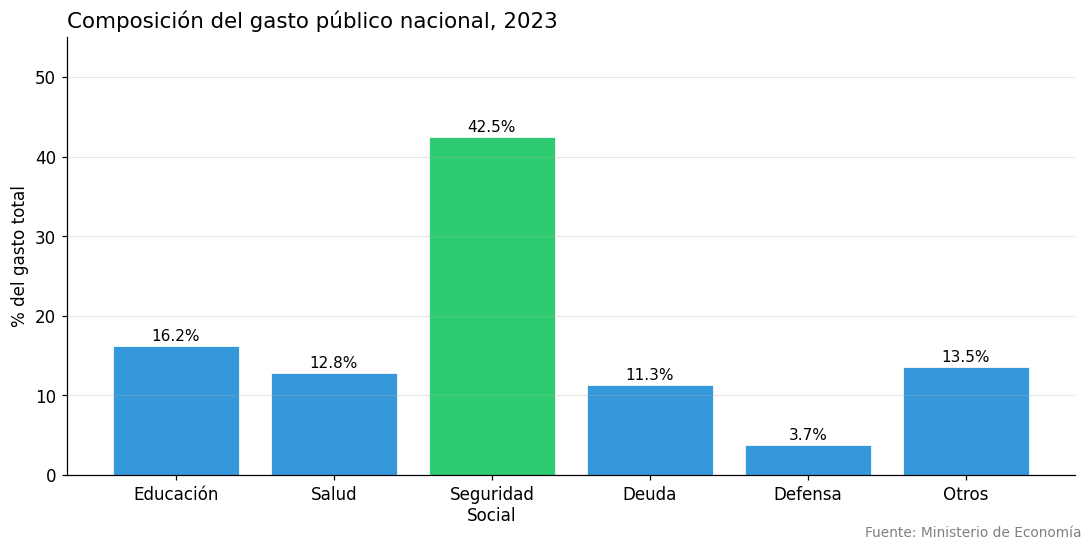

In [5]:
# Gasto público por área (barras verticales)
areas = ["Educación", "Salud", "Seguridad\nSocial", "Deuda", "Defensa", "Otros"]
gasto_pct = [16.2, 12.8, 42.5, 11.3, 3.7, 13.5]
colores = ['#2ecc71' if g == max(gasto_pct) else '#3498db' for g in gasto_pct]

fig, ax = plt.subplots(figsize=(10, 5))

barras = ax.bar(areas, gasto_pct, color=colores, edgecolor='white', linewidth=0.5)

# Etiquetas encima de cada barra
for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width() / 2., altura + 0.3,
            f'{altura:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_title("Composición del gasto público nacional, 2023", fontsize=14, loc='left')
ax.set_ylabel("% del gasto total")
ax.set_ylim(0, 55)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.99, 0.01, "Fuente: Ministerio de Economía", ha='right', fontsize=9, color='gray')
plt.tight_layout()
plt.show()


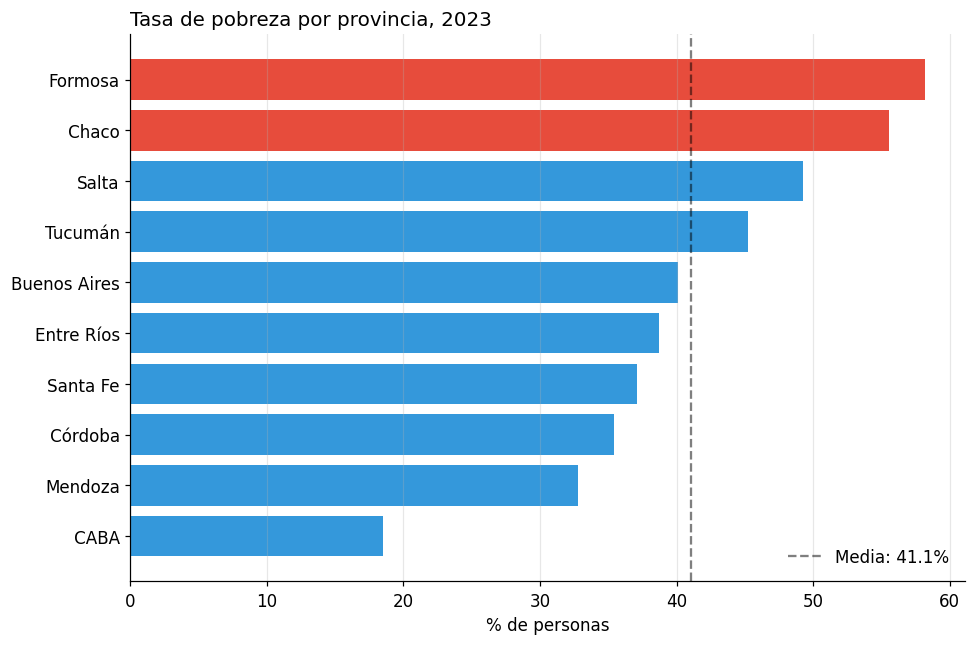

In [6]:
# Barras horizontales: mejor cuando hay muchas categorías o nombres largos
provincias = ["CABA", "Buenos Aires", "Córdoba", "Santa Fe", "Mendoza",
              "Tucumán", "Salta", "Entre Ríos", "Chaco", "Formosa"]
tasas = [18.5, 40.1, 35.4, 37.1, 32.8, 45.2, 49.3, 38.7, 55.6, 58.2]

# Ordenar de menor a mayor
orden = np.argsort(tasas)
provincias_ord = [provincias[i] for i in orden]
tasas_ord = [tasas[i] for i in orden]

fig, ax = plt.subplots(figsize=(9, 6))
colores = ['#e74c3c' if t > 50 else '#3498db' for t in tasas_ord]

ax.barh(provincias_ord, tasas_ord, color=colores)
ax.axvline(x=np.mean(tasas), color='black', linestyle='--', alpha=0.5, label=f'Media: {np.mean(tasas):.1f}%')

ax.set_title("Tasa de pobreza por provincia, 2023", fontsize=13, loc='left')
ax.set_xlabel("% de personas")
ax.legend(frameon=False)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## 5. Histogramas

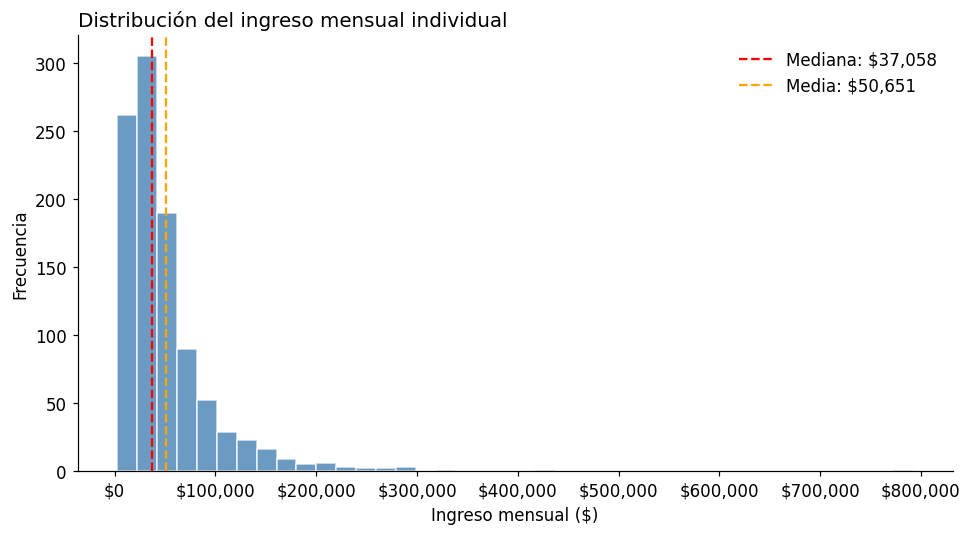

Nota: la media supera a la mediana → distribución sesgada a la derecha (pocos ingresos muy altos)


In [7]:
# Distribución de ingresos (simulada)
np.random.seed(42)
ingresos = np.random.lognormal(mean=10.5, sigma=0.8, size=1000)  # distribución asimétrica

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(ingresos, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.median(ingresos), color='red', linestyle='--', label=f'Mediana: ${np.median(ingresos):,.0f}')
ax.axvline(np.mean(ingresos), color='orange', linestyle='--', label=f'Media: ${np.mean(ingresos):,.0f}')

ax.set_title("Distribución del ingreso mensual individual", fontsize=13, loc='left')
ax.set_xlabel("Ingreso mensual ($)")
ax.set_ylabel("Frecuencia")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print("Nota: la media supera a la mediana → distribución sesgada a la derecha (pocos ingresos muy altos)")


---
## 6. Scatter plots

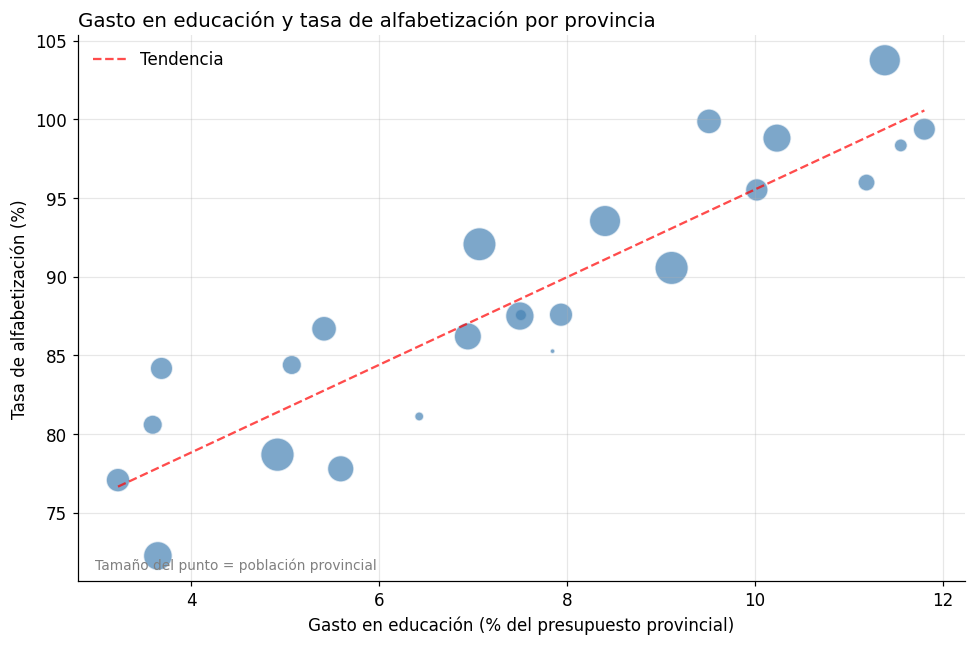

In [8]:
# Relación entre gasto en educación y tasa de alfabetización por provincia
np.random.seed(7)
gasto_educ = np.random.uniform(3, 12, 24)  # % del presupuesto provincial
alfabetizacion = 70 + gasto_educ * 2.5 + np.random.normal(0, 3, 24)  # correlación positiva + ruido
poblacion = np.random.uniform(0.1, 5, 24)  # millones (para tamaño de punto)

fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(gasto_educ, alfabetizacion,
                     s=poblacion * 100,  # tamaño proporcional a la población
                     alpha=0.7, color='steelblue', edgecolors='white')

# Línea de tendencia
m, b = np.polyfit(gasto_educ, alfabetizacion, 1)
x_line = np.linspace(gasto_educ.min(), gasto_educ.max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linestyle='--', alpha=0.7, label=f'Tendencia')

ax.set_title("Gasto en educación y tasa de alfabetización por provincia", fontsize=13, loc='left')
ax.set_xlabel("Gasto en educación (% del presupuesto provincial)")
ax.set_ylabel("Tasa de alfabetización (%)")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Leyenda para el tamaño
ax.text(0.02, 0.02, "Tamaño del punto = población provincial",
        transform=ax.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.show()


---
## 7. Heatmaps y matrices de correlación

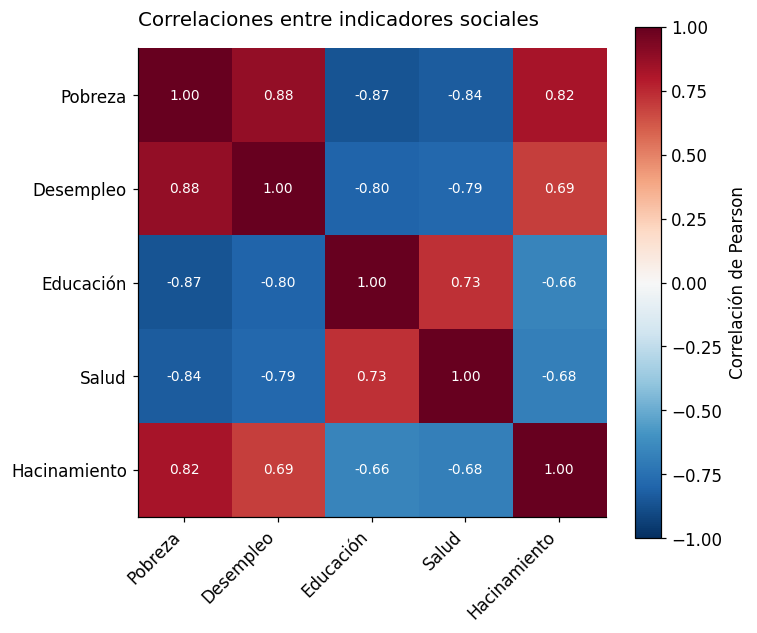

In [9]:
# Matriz de correlación entre indicadores sociales
np.random.seed(42)
n = 50
pobreza    = np.random.uniform(20, 60, n)
desempleo  = pobreza * 0.3 + np.random.normal(0, 2, n)
educacion  = 100 - pobreza * 0.8 + np.random.normal(0, 5, n)
salud      = 100 - pobreza * 0.5 + np.random.normal(0, 4, n)
hacinamiento = pobreza * 0.4 + np.random.normal(0, 3, n)

data = np.column_stack([pobreza, desempleo, educacion, salud, hacinamiento])
labels = ["Pobreza", "Desempleo", "Educación", "Salud", "Hacinamiento"]

# Calcular correlaciones
corr = np.corrcoef(data.T)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Correlación de Pearson')

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

# Anotar valores
for i in range(len(labels)):
    for j in range(len(labels)):
        color = 'white' if abs(corr[i, j]) > 0.6 else 'black'
        ax.text(j, i, f"{corr[i, j]:.2f}", ha='center', va='center', fontsize=9, color=color)

ax.set_title("Correlaciones entre indicadores sociales", fontsize=13, pad=15, loc='left')
plt.tight_layout()
plt.show()


---
## 8. Subplots: múltiples paneles

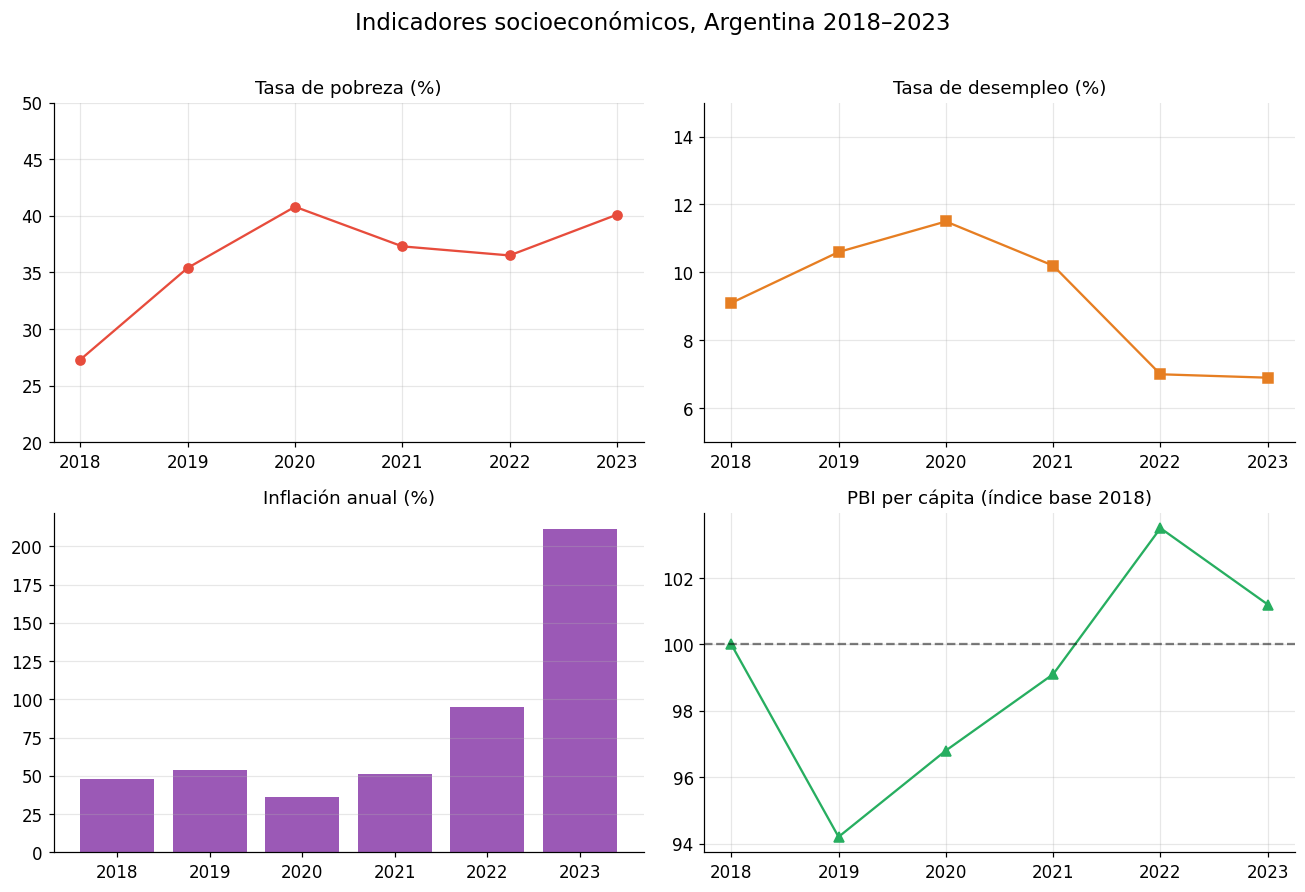

In [10]:
# Dashboard con 4 indicadores
anios = np.arange(2018, 2024)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Indicadores socioeconómicos, Argentina 2018–2023", fontsize=15, y=1.01)

# Panel 1: Pobreza
axes[0, 0].plot(anios, [27.3, 35.4, 40.8, 37.3, 36.5, 40.1], marker='o', color='#e74c3c')
axes[0, 0].set_title("Tasa de pobreza (%)")
axes[0, 0].set_ylim(20, 50)
axes[0, 0].grid(alpha=0.3)

# Panel 2: Desempleo
axes[0, 1].plot(anios, [9.1, 10.6, 11.5, 10.2, 7.0, 6.9], marker='s', color='#e67e22')
axes[0, 1].set_title("Tasa de desempleo (%)")
axes[0, 1].set_ylim(5, 15)
axes[0, 1].grid(alpha=0.3)

# Panel 3: Inflación
axes[1, 0].bar(anios, [47.6, 53.8, 36.1, 50.9, 94.8, 211.4], color='#9b59b6')
axes[1, 0].set_title("Inflación anual (%)")
axes[1, 0].grid(axis='y', alpha=0.3)

# Panel 4: PBI per cápita (índice base 2018=100)
axes[1, 1].plot(anios, [100, 94.2, 96.8, 99.1, 103.5, 101.2], marker='^', color='#27ae60')
axes[1, 1].axhline(y=100, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_title("PBI per cápita (índice base 2018)")
axes[1, 1].grid(alpha=0.3)

for ax in axes.flat:
    ax.set_xticks(anios)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## 9. Exportar gráficos

Gráficos guardados: pobreza_2018_2023.png y .svg


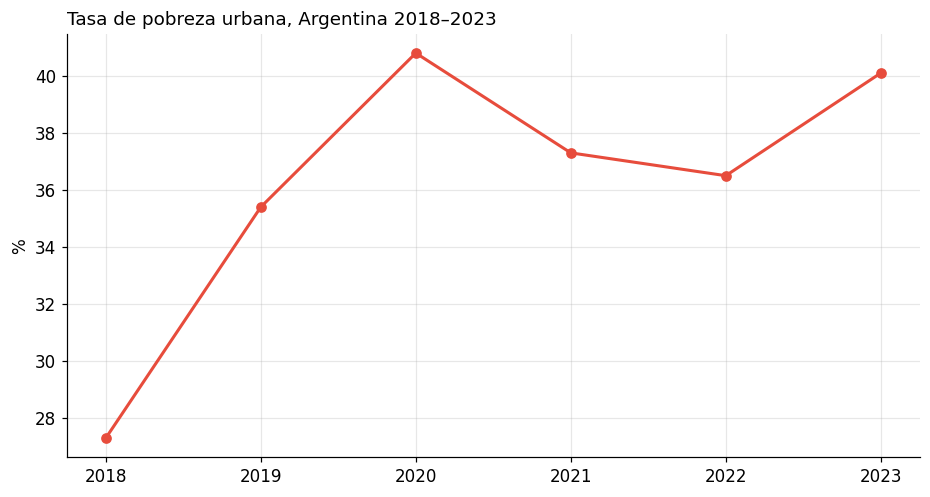

In [11]:
# Guardar un gráfico con alta resolución
fig, ax = plt.subplots(figsize=(10, 5))
anios = np.arange(2018, 2024)
ax.plot(anios, [27.3, 35.4, 40.8, 37.3, 36.5, 40.1], marker='o', color='#e74c3c', linewidth=2)
ax.set_title("Tasa de pobreza urbana, Argentina 2018–2023", loc='left')
ax.set_ylabel("%")
ax.grid(alpha=0.3)

# Guardar en diferentes formatos
fig.savefig("pobreza_2018_2023.png", dpi=300, bbox_inches='tight')  # para documentos
fig.savefig("pobreza_2018_2023.svg", bbox_inches='tight')           # vectorial (editable)

print("Gráficos guardados: pobreza_2018_2023.png y .svg")
plt.show()


---
## 10. Ejercicios

### Ejercicio 1
Usando los datos de la siguiente tabla, creá un gráfico de barras horizontales que muestre el porcentaje de hogares con acceso a internet por región, ordenado de mayor a menor. Incluí título, etiquetas de ejes y fuente.

```python
regiones = ["CABA", "Pampeana", "Patagonia", "Cuyo", "NOA", "NEA"]
acceso_internet = [82.3, 71.5, 68.9, 62.4, 51.8, 47.2]  # %
```

In [12]:
# Tu solución aquí


### Ejercicio 2
Creá un subplot con 2 paneles (uno al lado del otro):
- **Izquierda**: histograma de la distribución de tasas de mortalidad infantil por provincia (usá `np.random.normal(10, 4, 24).clip(2, 25)` como datos simulados).
- **Derecha**: scatter plot mostrando la relación entre esas tasas de mortalidad y un índice de pobreza simulado (`np.random.uniform(20, 60, 24)`).

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)
mortalidad = np.random.normal(10, 4, 24).clip(2, 25)
pobreza = np.random.uniform(20, 60, 24)

# Tu solución aquí
